# NYC Airbnb Room Type Classification

**Dataset:** [New York City Airbnb Open Data](https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data) (Kaggle)

**Goal:** Predict the `room_type` of an Airbnb listing (`Entire home/apt`, `Private room`, or `Shared room`)
using listing attributes such as price, location, availability, and review activity.

**What this notebook covers (the full ML lifecycle):**

1. Problem framing & data loading
2. Exploratory Data Analysis (EDA) — univariate, bivariate, skewness, outliers
3. Data cleaning & feature engineering
4. Train / test split
5. Preprocessing with `ColumnTransformer` + `Pipeline`
6. Baseline model
7. Multiple candidate algorithms (Logistic Regression, Decision Tree, Random Forest, Gradient Boosting)
8. Model comparison (cross-validation)
9. Hyperparameter tuning of the best model
10. Final evaluation on the untouched test set
11. Feature importance
12. Saving the final pipeline (model artifact)
13. Conclusion & next steps



## 1. Import Libraries


In [1]:
import pandas as pd 
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("AB_NYC_2019.csv")

In [3]:
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [5]:
df.describe(include='all')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


In [6]:
df.shape

(48895, 16)

In [7]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

## 3. Exploratory Data Analysis (EDA)

We explore the data in the standard order every ML engineer follows:

- Missing values
- Univariate analysis (one variable at a time — distributions, skewness)
- Bivariate analysis (relationship between features and the target)
- Correlation between numeric features
- Outlier inspection


### 3.1 Missing Values

In [8]:
missing = df.isnull().sum()
missing[missing>0]

name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

### 3.2 Target Variable — `room_type`

In [9]:
df['room_type'].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

<Axes: xlabel='room_type', ylabel='count'>

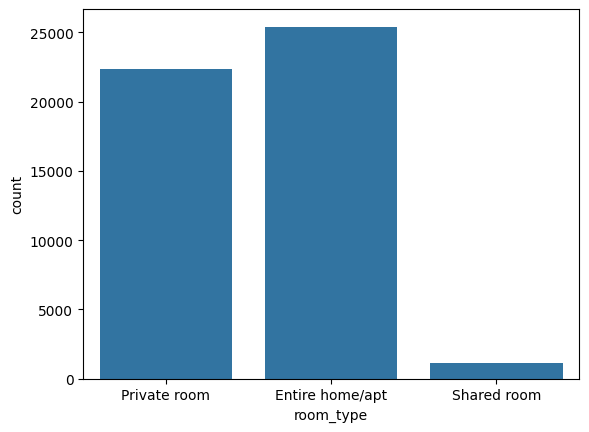

In [10]:
sns.countplot(x=df['room_type'], data = df)

### 3.3 Univariate Analysis — Numeric Features

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>],
       [<Axes: title={'center': 'calculated_host_listings_count'}>,
        <Axes: title={'center': 'availability_365'}>]], dtype=object)

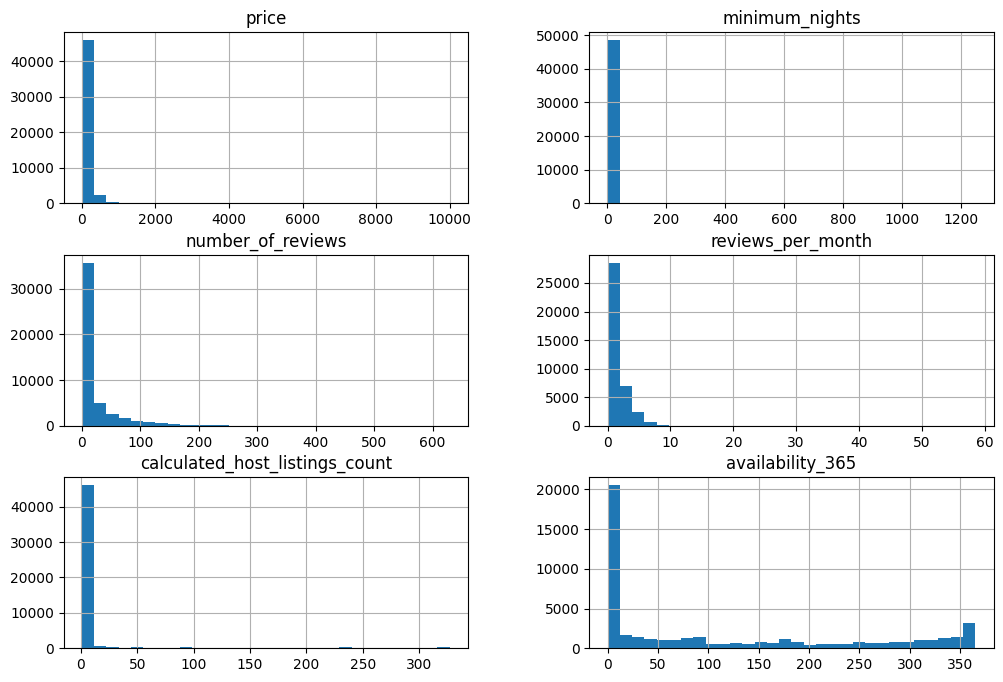

In [11]:
# numerical_cols = df.select_dtypes(include='number')
# numerical_cols.columns

numerical_cols = ["price", "minimum_nights", "number_of_reviews",
                 "reviews_per_month", "calculated_host_listings_count",
                 "availability_365"]

df[numerical_cols].hist(bins=30, figsize=(12, 8))

### 3.4 Univariate Analysis — Categorical Features

<Axes: xlabel='neighbourhood_group', ylabel='count'>

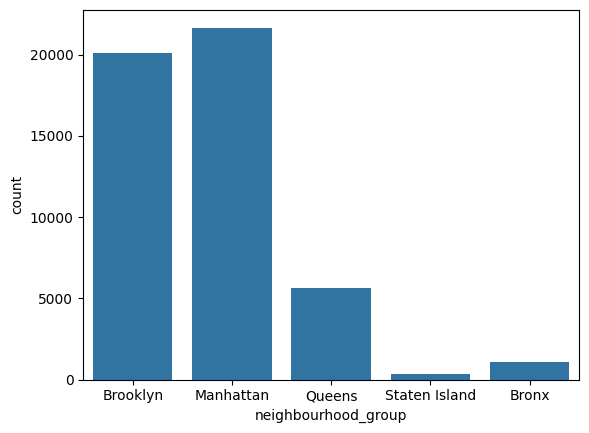

In [12]:
sns.countplot(data=df, x='neighbourhood_group')

### 3.5 Bivariate Analysis — Features vs Target

<Axes: xlabel='room_type', ylabel='price'>

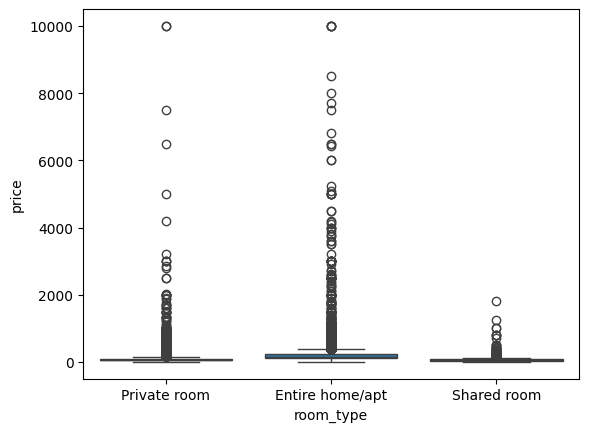

In [13]:
sns.boxplot(x='room_type', y='price', data=df)

### 3.6 Correlation Between Numeric Features

<Axes: >

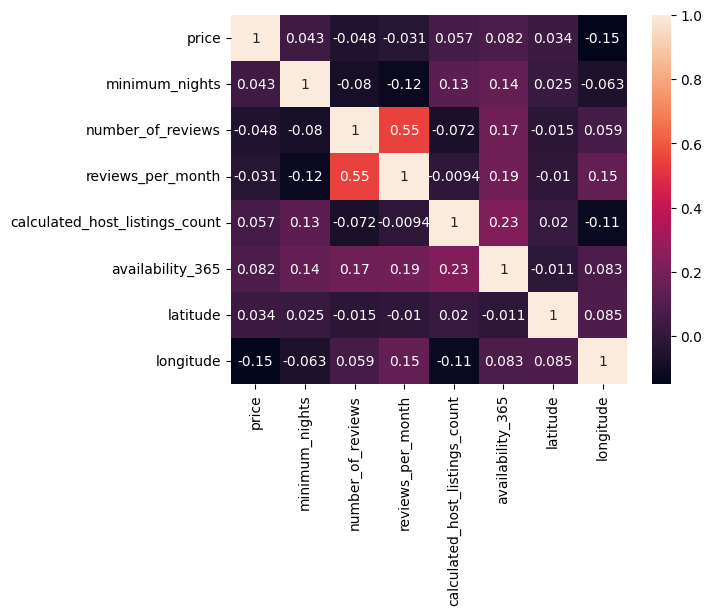

In [14]:
corr = df[numerical_cols + ['latitude', 'longitude']].corr()
sns.heatmap(corr,annot=True)

### 3.7 Geographic Distribution (Bonus Visual)

<Axes: xlabel='longitude', ylabel='latitude'>

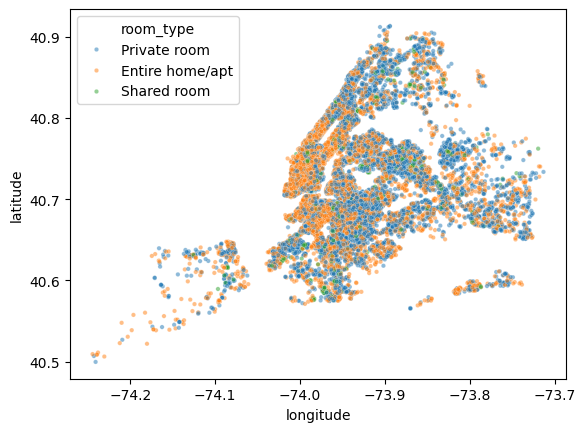

In [31]:
sns.scatterplot(x='longitude', y='latitude',data=df, hue='room_type', alpha=0.5, s=10)

## 4. Data Cleaning & Feature Engineering

Steps:
1. Drop columns that are pure identifiers or free text and carry no generalizable signal for a
   tabular model (`id`, `name`, `host_id`, `host_name`, `last_review`).
2. Fill missing `reviews_per_month` with `0` (no reviews yet).
3. Cap extreme outliers in `price` and `minimum_nights` using percentile clipping, so a handful of
   data-entry errors (e.g. $10,000/night, 1,250 minimum nights) don't distort the model.
4. Separate features (`X`) from the target (`y`).


In [16]:
#1. Drop Colunmns that dont help us.
df_clean = df.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review'])

#2. No reviews yet -> 0 reviews per month, not missing
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)

In [17]:
#3. Cap Extreme outliers instead of deleting rows.
price_cap  = df_clean['price'].quantile(0.99)
nights_cap = df_clean['minimum_nights'].quantile(0.99)

df_clean['price'] = df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper=nights_cap)

df_clean

# df_clean = df_clean[df_clean['price'] < price_cap]
# df_clean = df_clean[df_clean['minimum_nights'] < nights_cap]


,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...
48890,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,0.00,2,9
48891,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,0.00,2,36
48892,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,0.00,1,27
48893,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,0.00,6,2


In [18]:
X = df_clean.drop(columns=['room_type'])
y = df_clean['room_type']

## 5. Train / Test Split

We hold out 20% of the data as a **test set** that is never touched during model selection or
tuning — it is only used once, at the very end, to report the final, honest performance.
`stratify=y` keeps the same class proportions in both splits, which matters because the target is
imbalanced.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

## 6. Preprocessing: `ColumnTransformer` + `Pipeline`

Production ML code should never manually transform train/test data with separate lines — it's
error-prone and leaks information. Instead we build a single, reusable `ColumnTransformer`:

- **Numeric features** → median imputation + standard scaling
- **Categorical features** → most-frequent imputation + one-hot encoding

This transformer will be the first step of *every* model pipeline below, so preprocessing is
learned only on training data and applied consistently everywhere (no data leakage).

In [20]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.compose import ColumnTransformer

In [21]:
df_clean.skew(numeric_only=True)

latitude                          0.237167
longitude                         1.284210
price                             2.776321
minimum_nights                    2.360347
number_of_reviews                 3.690635
reviews_per_month                 3.300723
calculated_host_listings_count    7.933174
availability_365                  0.763408
dtype: float64

In [22]:
numerical_cols = ["latitude","longitude","price", "minimum_nights", "number_of_reviews",
                 "reviews_per_month", "calculated_host_listings_count",
                 "availability_365"]

categorical_cols = ['neighbourhood_group', 'neighbourhood']

#1. Pipeline -> for Numeric Columns
numeric_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="median")),
    ('skewness', PowerTransformer(method='yeo-johnson')),
    ('scale', StandardScaler())
])

#2. Pipeline -> for Categorical Columns
categorical_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy="most_frequent")),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ("numerical", numeric_pipeline, numerical_cols),
    ("categorical", categorical_pipeline, categorical_cols)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

## 8. Trying Multiple Algorithms

We now compare several models, each wrapped in its own pipeline with the **same** preprocessor. We
evaluate each with 3-fold **stratified cross-validation** on the training set (never touching the
test set yet), so the comparison is fair and robust.

Models tried:
1. Logistic Regression — simple, interpretable linear baseline
2. Decision Tree — a single non-linear model, prone to overfitting
3. Random Forest — an ensemble of trees, usually a strong general-purpose model
4. Gradient Boosting — sequential ensemble, often the most accurate of the classics


**SMOTE (Synthetic Minority Oversampling)**.                         
for class IMbalance
-----------------------------------------
1. High chances of Overfitting.
2. Data Leakage

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

In [24]:
models = {
    "LogisticRegression" : LogisticRegression(class_weight='balanced', random_state=42),
    "Decision Tree" : DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Rnadom Forest" : RandomForestClassifier(class_weight='balanced', random_state=42),
    "Gradient Boosting" : GradientBoostingClassifier(random_state=42)
}

In [25]:
for name,model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor",preprocessor),
        ("classifier", model)
    ])
    
    # Accuracy alone can be misleading on imbalanced classes, so we use macro f1
    # both: plain accuracy and macro f1 (which treats every class equally)
    
    accuracy = cross_val_score(pipe, X_train, y_train,cv=3,scoring="accuracy")
    macrof1 = cross_val_score(pipe, X_train, y_train,cv=3,scoring="f1_macro")
    
    print(f"{name} -> Accuracy: {accuracy.mean():.3f} , F1: {macrof1.mean():.3f}")

c:\Users\SAHIL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\SAHIL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://sciki

LogisticRegression -> Accuracy: 0.727 , F1: 0.575
Decision Tree -> Accuracy: 0.783 , F1: 0.653
Rnadom Forest -> Accuracy: 0.850 , F1: 0.732
Gradient Boosting -> Accuracy: 0.850 , F1: 0.707


## 9. Hyperparameter Tuning

We pick the best-performing model from the comparison above (whichever one that turns out to be) and
search over *its* key hyperparameters using `RandomizedSearchCV` (cheaper than an exhaustive grid
search, while still exploring the space well). We keep optimizing for **macro-F1** since the classes
are imbalanced.

In [26]:
from sklearn.model_selection import RandomizedSearchCV

best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   RandomForestClassifier(class_weight='balanced'))
])

param_distribution = {
    "classifier__n_estimators" : [100,200,150,300],
    "classifier__max_depth": [8, 12, 15, 20, None],
    "classifier__min_samples_split": [2, 5, 10],
}

search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=param_distribution,
    n_iter=10,
    cv=3,
    scoring="f1_macro",
    random_state=42
    )

search.fit(X_train, y_train)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__max_depth': [8, 12, ...], 'classifier__min_samples_split': [2, 5, ...], 'classifier__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also 

In [27]:
print("Best Parameters: ", search.best_params_)
print("Best CV Macro-F1: ", search.best_score_)

Best Parameters:  {'classifier__n_estimators': 100, 'classifier__min_samples_split': 2, 'classifier__max_depth': None}
Best CV Macro-F1:  0.7335947313295866


## 10. Final Evaluation on the Test Set

This is the *only* time we touch the held-out test set. It gives us an honest estimate of how the
final tuned model would perform on completely unseen listings.

In [28]:
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score

best_pipeline = search.best_estimator_
y_pred = best_pipeline.predict(X_test)


print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"F1 Score: {f1_score(y_test, y_pred, average="macro")}")

Accuracy Score: 0.8557263262270699
F1 Score: 0.7388483211422718


<Axes: >

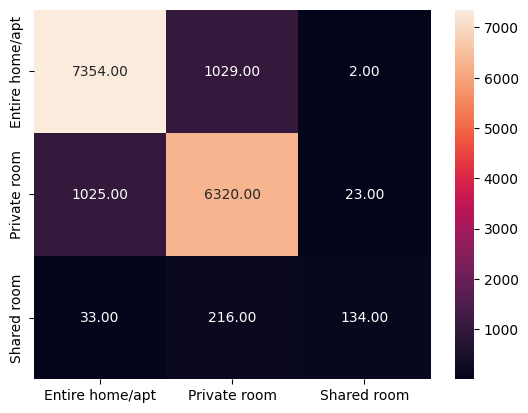

In [29]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt=".2f",
            xticklabels=best_pipeline.classes_, yticklabels=best_pipeline.classes_)


## 11. Saving the Final Model Artifact

In production, the entire pipeline (preprocessing **and** model together) is serialized as a single
artifact, so a new listing can be scored with one call  no manual preprocessing required at
inference time.